# 1, 라이브러리


## Gensim
단어와 문서의 대량 말뭉치를 기반으로 벡터 공간에 임베딩 할 때 사용

* 주요기능  
1. Word2Vec/ Fasttext/ Doc2Vec와 같이 단어나 문서를 고차원 벡터로 변환하여 의미론적 연산을 가능하게 함
2. 데이터를 알아서 주제별로 분류해줌
3. 특정문서와 가장 유사한 문서를 고속으로 찾아냄

* 트랜스포머와 Gensim 차이
Gensim은 하나의 단어에 하나의 고정된 벡터만 부여됨
예시) 배(이동수단) vs 배(과일)
트랜스포머는 어텐션 매커니즘을 통해 문장속에서 단어가 쓰인 문맥을 실시간으로 파악


In [4]:
!pip install gensim

from gensim.models import Word2Vec, FastText
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
import nltk
import re

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# 2, 데이터로드 , 텍스트 전처리 , train / test 분리 , EDA

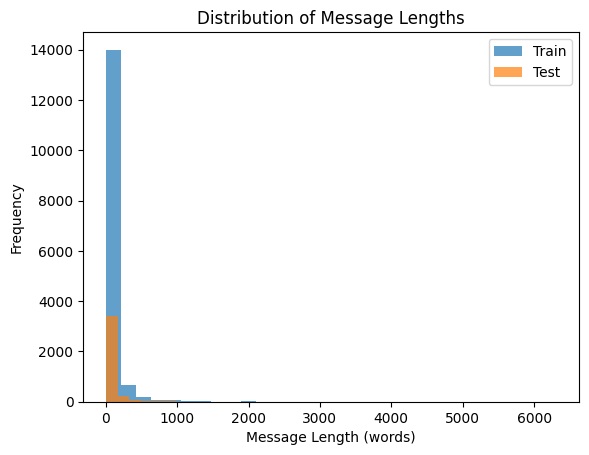

평균 길이: 90.27984876625099
최대 길이: 6315
95분위수: 275.0


In [5]:
# 데이터 로드
# subset all을 통해 전체 데이터를 가져오고, 헤더,서명,인용문 제거를 통해 카테고리 정보를 제거하여 모델이 쉽게 정답을 맞추는걸 방지
news_data = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
texts = news_data.data
labels = news_data.target

# trian/test 분리
train_inputs, test_inputs, train_targets, test_targets = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

# 전처리
# 불용어를 가져오는 코드
# the, si ,a , in 같은게 불용어
# nltk에서 직접 만들어둔 불용어 리스트 가져오는 코드
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                              # 소문자 변환
    text = re.sub(r'[^a-zA-Z\s]', '', text)         # 특수문자 제거
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]  # 불용어 + 2글자 이하 제거
    return ' '.join(tokens)

# 전처리 적용
train_inputs = [clean_text(text) for text in train_inputs]
test_inputs = [clean_text(text) for text in test_inputs]

# EDA
# 문서 길이 계산
train_lengths = [len(word_tokenize(text)) for text in train_inputs]
test_lengths = [len(word_tokenize(text)) for text in test_inputs]

# 히스토그램 시각화
plt.hist(train_lengths, bins=30, alpha=0.7, label='Train')
plt.hist(test_lengths, bins=30, alpha=0.7, label='Test')
plt.xlabel('Message Length (words)')
plt.ylabel('Frequency')
plt.title('Distribution of Message Lengths')
plt.legend()
plt.show()

# 통계 출력
print("평균 길이:", np.mean(train_lengths))
print("최대 길이:", np.max(train_lengths))
print("95분위수:", np.percentile(train_lengths, 95))


## max_len은 280
95분위수가 275이므로 5% 정도의 손실만 발생하도록 설정
만약 6315로 설정하면 낭비가 너무 심함

# 3, 토큰화 , Word2Vec임베딩

등장배경 : 컴퓨터는 단어 간의 관계를 표현할 수 없다는 단점이 있었다(사과와 바나나가 과일이라는 관계)

Word2Vec은 주변 단어들의 문맥을 학습함으로 써 해결

*예시
"나는 아침에 상큼한 [   ]을 먹었다"
"나는 디저트로 달콤한 [   ]를 먹었다"

위 빈칸의 정답이 사과와 바나나
두 단어든 주변에 아침 , 먹었다, 달콤한 같은 공통된 단어들을 보고 사과와 바나나가 의미가 비슷하다고 판단하여 벡터 위치를 가깝게 배치


## Word2Vec의 CBOW vs Skip-gram

1. CBOW
방식 : 주변에 있는 단어들을 보고 , 가운데에 있는 중심 단어를 예측
특징 : 상대적으로 빠름

2. Skip-gram
방식 : 가운데 있는 중심 단어 하나를 보고 , 주변에 올 단어들을 예측
특징 : 단어간의 미묘한 관계를 훨씬 더 잘 잡아냄 , 특히 자주 등장하지 않는 희긔한 단어도 비교적 잘 학습하는 경향이 있어 성능이 더 좋음


## 단어를 128차원으로 하는이유?
차원이 낮으면 표현할 수 있는 정보가 너무 작음
차원이 높으면 메모리를 많이 먹고 , 과적합 발생 우려

## window를 100으로 해서 단어가 많은 관계를 보고 학습하는게 더 나은거 아닌가?

예시)
"나는 사과를 먹었다"  →  "사과" 옆에 "먹었다" 있음 → 과일
"나는 사과를 했다"   →  "사과" 옆에 "했다" 있음 → 사죄

너무 멀이 있는 단어까지 보면 오히려 의미가 흐려짐

window 2-3은 문법적 관계 학습에 유리
5~10은 의미적 학습에 유리

## 0번에 패딩을 빈자리로 만드는 이유

모든 데이터의 길이는 다름
LSTM 모델은 배치로 한꺼번에 처리하기 때문에 모든 입력의 길이가 같아야함
이 문제를 패딩으로 해결
그 과정에서 0번 인데스를 아무 의미가 없는 빈자리로 만들어서 모델이 혼동을 겪지 않도록 하는거

In [6]:
# 토큰화
train_sentences = [word_tokenize(text) for text in train_inputs]
test_sentences = [word_tokenize(text) for text in test_inputs]

# Word2Vec 학습
# vector_size=128 : 각 단어를 128차원 벡터로 표현 ?
# window = 5 : 주변 5개 단어를 보고 학습
# min_count= 1 : 1번 이상 등장한 단어 모두 학습
# sg = 1 : Skip-gram 방식 사용
word2vec_model = Word2Vec(sentences=train_sentences, vector_size=128, window=5, min_count=1, sg=1)

# 단어 → 인덱스 딕셔너리 생성
# 예시 {"computer": 1, "science": 2, "news": 3, ...}
# +1 하는 이유 : 0번은 패딩(빈자리)용으로 비워두기 위해?
word2idx_word2vec = {word: idx + 1 for idx, word in enumerate(word2vec_model.wv.index_to_key)}

# 임베딩 행렬 생성
# (단어수+1) x 128 크기의 빈 행렬 생성?
word2vec_matrix = np.zeros((len(word2idx_word2vec) + 1, 128))
for word, idx in word2idx_word2vec.items():
    word2vec_matrix[idx] = word2vec_model.wv[word]

print("Word2Vec 임베딩 행렬 크기:", word2vec_matrix.shape)

Word2Vec 임베딩 행렬 크기: (101931, 128)


# 4, Dataset , DataLoader


## 임베딩과 데이터셋의 정확한 구분
Word2Vec → 단어:벡터 사전(행렬) 생성
Dataset  → 문서를 인덱스 번호로 변환
LSTM     → 인덱스를 벡터로 변환 후 분류

In [7]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = word_tokenize(self.texts[idx])
        # 단어를 인덱스 번호로 변환 (모르는 단어는 0)
        encoded = [self.word2idx.get(token, 0) for token in tokens]
        # max_len보다 짧으면 0으로 패딩, 길면 자르기
        if len(encoded) < self.max_len:
            encoded += [0] * (self.max_len - len(encoded))
        else:
            encoded = encoded[:self.max_len]
        return torch.tensor(encoded, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

max_len = 280

# Word2Vec Dataset & DataLoader
train_dataset = TextDataset(train_inputs, train_targets, word2idx_word2vec, max_len)
test_dataset = TextDataset(test_inputs, test_targets, word2idx_word2vec, max_len)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("훈련 배치 수:", len(train_loader))
print("테스트 배치 수:", len(test_loader))

훈련 배치 수: 236
테스트 배치 수: 59


# 5, LSTM
순서가 있는 데이터를 처리하는 모델
뉴스 문장을 읽을 떄 앞 단어를 기억하면서 뒤 단어를 이해하는 방식

예시 )
"나는 오늘 야구를 봤다"
→ "야구"를 볼 때 앞에 "오늘"이 있었다는 걸 기억하면서 이해

등장배경) RNN의 치명적인 약점인 문장을 읽을 떄 단어를 하나씩 순서대로 입력받아 히든 스테이트에 업데이트함, 이로인해 문장이 길어지면 앞쪽 중요한 정보가 뒤쪽까지 온전히 전달하지 못하는 문제가 발생했음

*핵심 방법론
Cell State : 내부에 컨베이어 벨트 같은 일직선 통로 , 이 벨트 위에서 정보가 전달할떄 세개의 게이트를 두어 정보를 제어

Gate : 정보를 더하거나 뺴기 위한 수학정 장치 , 시그모이드 함수를 사용해 0(모두 삭제)에서 1(모두 기억) 사이의 값으로 정보를 조절
1. 삭제 게이트 : 쓸모없는 정보를 지움
2. 입력 게이트 : 유용한 정보를 추가
3. 출력 게이트 : 최종적으로 히든스테이트를 만들어냄  

문제점 : 순서대로 입력해서 연산을 함 , 병렬 연산이 불가하여 학습 속도가 너무 느림 이를 해결하기 위해 트랜스포머 등장



In [8]:
class TextLSTM(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, output_dim, num_layers=2, dropout=0.5):
        super(TextLSTM, self).__init__()
        num_embeddings, embedding_dim = embedding_matrix.shape

        # 임베딩 레이어: word2vec_matrix를 가중치로 사용
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float).to(device), freeze=False
        )
        # LSTM 레이어
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=dropout, bidirectional=True)
        # 분류 레이어
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)           # 인덱스 → 벡터
        _, (hidden, _) = self.lstm(embedded)   # 벡터 → 문맥 파악
        output = self.fc(hidden[-1])           # 마지막 hidden → 카테고리 점수
        return output

hidden_dim = 128
output_dim = 20

model_word2vec = TextLSTM(word2vec_matrix, hidden_dim, output_dim).to(device)
print(model_word2vec)

TextLSTM(
  (embedding): Embedding(101931, 128)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=128, out_features=20, bias=True)
)


# 6, 학습

In [9]:
def train(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for texts, labels in loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_word2vec.parameters(), lr=0.005)

for epoch in range(10):
    loss = train(model_word2vec, train_loader, criterion, optimizer)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

Epoch 1, Loss: 1.9805
Epoch 2, Loss: 1.1895
Epoch 3, Loss: 0.7225
Epoch 4, Loss: 0.4421
Epoch 5, Loss: 0.2881
Epoch 6, Loss: 0.2178
Epoch 7, Loss: 0.1734
Epoch 8, Loss: 0.1480
Epoch 9, Loss: 0.1344
Epoch 10, Loss: 0.1330


## 평가

In [10]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    return correct / total

accuracy = evaluate(model_word2vec, test_loader)
print(f"Word2Vec 정확도: {accuracy:.4f}")

Word2Vec 정확도: 0.6477


#7, CBOW 사용

In [11]:
# CBOW 임베딩
word2vec_model_cbow = Word2Vec(sentences=train_sentences, vector_size=128, window=5, min_count=1, sg=0)

word2idx_cbow = {word: idx + 1 for idx, word in enumerate(word2vec_model_cbow.wv.index_to_key)}

word2vec_matrix_cbow = np.zeros((len(word2idx_cbow) + 1, 128))
for word, idx in word2idx_cbow.items():
    word2vec_matrix_cbow[idx] = word2vec_model_cbow.wv[word]

# Dataset & DataLoader
train_dataset_cbow = TextDataset(train_inputs, train_targets, word2idx_cbow, max_len)
test_dataset_cbow = TextDataset(test_inputs, test_targets, word2idx_cbow, max_len)

train_loader_cbow = DataLoader(train_dataset_cbow, batch_size=64, shuffle=True)
test_loader_cbow = DataLoader(test_dataset_cbow, batch_size=64, shuffle=False)

# 모델 학습
model_cbow = TextLSTM(word2vec_matrix_cbow, hidden_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cbow.parameters(), lr=0.005)

for epoch in range(10):
    loss = train(model_cbow, train_loader_cbow, criterion, optimizer)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

# 평가
accuracy_cbow = evaluate(model_cbow, test_loader_cbow)
print(f"Word2Vec CBOW 정확도: {accuracy_cbow:.4f}")

Epoch 1, Loss: 2.0795
Epoch 2, Loss: 1.2436
Epoch 3, Loss: 0.7221
Epoch 4, Loss: 0.4517
Epoch 5, Loss: 0.3015
Epoch 6, Loss: 0.2194
Epoch 7, Loss: 0.1772
Epoch 8, Loss: 0.1539
Epoch 9, Loss: 0.1370
Epoch 10, Loss: 0.1340
Word2Vec CBOW 정확도: 0.6175


## CBOW vs skip-gram 정확도
Word2Vec CBOW 정확도: 0.6318
Word2Vec skip-gram 정확도: 0.6321

회고) 성능 차이가 별로 안난다.
LSTM을 통해 벡터 값이 업데이트 되면서 보완되어서?

# 8, FastText 사용

등장배경)Word2Vec의 2가지 문제점이 있었음
1. OOV(사전에 없는 단어) 문제 - Word2Vec은 하나의 단어를 하나로 매핑해서 학습 데이터에 없던 새로운 단어가 등장하면 벡터가 아예 없음

2. 학습 데이터에 한 두 번만 등장한 단어는 학습이 충분히 되지 않아 벡터값이 엉망

*방법론
서브워드 - 단어를 더 작은 단위로 나누어서 학습
(핵심 매커니즘)
1. n-gram을 통한 단어 쪼개기
예시) 3-grams: <ap, app, ppl, ple, le>
2. 내부 단어들의 의미 공유  -  apples 도 apple을 학습을 통해 벡터값 유추 가능

오타에도 유용!

In [12]:
# FastText 학습
fasttext_model = FastText(sentences=train_sentences, vector_size=128, window=5, min_count=1, sg=1)

word2idx_fasttext = {word: idx + 1 for idx, word in enumerate(fasttext_model.wv.index_to_key)}

fasttext_matrix = np.zeros((len(word2idx_fasttext) + 1, 128))
for word, idx in word2idx_fasttext.items():
    fasttext_matrix[idx] = fasttext_model.wv[word]

# Dataset & DataLoader
train_dataset_fasttext = TextDataset(train_inputs, train_targets, word2idx_fasttext, max_len)
test_dataset_fasttext = TextDataset(test_inputs, test_targets, word2idx_fasttext, max_len)

train_loader_fasttext = DataLoader(train_dataset_fasttext, batch_size=64, shuffle=True)
test_loader_fasttext = DataLoader(test_dataset_fasttext, batch_size=64, shuffle=False)

# 모델 학습
model_fasttext = TextLSTM(fasttext_matrix, hidden_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_fasttext.parameters(), lr=0.005)

for epoch in range(10):
    loss = train(model_fasttext, train_loader_fasttext, criterion, optimizer)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

# 평가
accuracy_fasttext = evaluate(model_fasttext, test_loader_fasttext)
print(f"FastText 정확도: {accuracy_fasttext:.4f}")

Epoch 1, Loss: 2.0736
Epoch 2, Loss: 1.2426
Epoch 3, Loss: 0.7952
Epoch 4, Loss: 0.5219
Epoch 5, Loss: 0.3774
Epoch 6, Loss: 0.2763
Epoch 7, Loss: 0.2241
Epoch 8, Loss: 0.1910
Epoch 9, Loss: 0.1598
Epoch 10, Loss: 0.1488
FastText 정확도: 0.6499


## FastText 정확도: 0.6499




# Glove

등장 배경)Word2Vec도 좋고 , 옛날 방식도 좋아 둘을 섞어보자는 아이디어에서 출발
1. LSA -전체 문서에서 단어들이 총 몇번 등장했는지 표를 만들어 통계를 내는 방식으로 글로버한 통계 정보를 반영
2. Word2Vec - 단어 주변의 window만 보기 때문에 데이터 전체의 통계 정보는 제대로 활용하지 못하지만 단어간의 의미적 관계를 잘 찾음

*방법론
동시 출현 확률 - 두 단어의 관계는 제 3의 단어들과 동시에 등창할 확률의 비율을 통해 알수 있다.
-> 이를 통해 단어들의 동시 출현 빈도수 표를 미리 만들고 , 학습을 통해 만들어질 단어 벡터들의 내적 값이 , 미리 준비해놓은 표와 비율이 똑같아 지도록 손실 함수를 생성



## 벡터들의 내적값?
두 단어는 벡터를 가지고 그 벡터들의 유사도


## 표를 벡터값에 핏하게 맞추는데 벡터 값이 굳이 필요한가?

1. 차원의 저주
만약 전체 단어가 10만개이면 100억 칸의 표를 가지게 되는데 , 단 하나의 벡터로 만들 수 있기 때문
-> 똑같이 벡터에서도 100억 칸을 가지는거 아닌가?
-> 100억 칸 중 실제로 숫자가 채워지는 칸은 1~2%  그 100억 칸 중 0은 메모리에 올리지 않음
2. Generaliztion
만약 사과와 망고라는 단어가 단 한번도 같은 문장에 쓰인적이 없다면 표에서 유사도는 0이다.
하지만 Glove를 통해 벡터 공간에 핏하게 맞추다 보면 다른 단어들로 인해 가까운 위치에 벡터가 정렬하게 됨

In [14]:
import gensim.downloader as api

glove_model = api.load('glove-wiki-gigaword-100')
print("GloVe 로드 완료")



# GloVe 임베딩 행렬 생성
word2idx_glove = {word: idx + 1 for idx, word in enumerate(glove_model.key_to_index)}

glove_matrix = np.zeros((len(word2idx_glove) + 1, 100))
for word, idx in word2idx_glove.items():
    glove_matrix[idx] = glove_model[word]

# Dataset & DataLoader
train_dataset_glove = TextDataset(train_inputs, train_targets, word2idx_glove, max_len)
test_dataset_glove = TextDataset(test_inputs, test_targets, word2idx_glove, max_len)

train_loader_glove = DataLoader(train_dataset_glove, batch_size=64, shuffle=True)
test_loader_glove = DataLoader(test_dataset_glove, batch_size=64, shuffle=False)

# 모델 학습
model_glove = TextLSTM(glove_matrix, hidden_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_glove.parameters(), lr=0.005)

for epoch in range(10):
    loss = train(model_glove, train_loader_glove, criterion, optimizer)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

# 평가
accuracy_glove = evaluate(model_glove, test_loader_glove)
print(f"GloVe 정확도: {accuracy_glove:.4f}")

[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe 로드 완료
Epoch 1, Loss: 1.9368
Epoch 2, Loss: 1.1761
Epoch 3, Loss: 0.8462
Epoch 4, Loss: 0.5896
Epoch 5, Loss: 0.4118
Epoch 6, Loss: 0.3040
Epoch 7, Loss: 0.2472
Epoch 8, Loss: 0.2036
Epoch 9, Loss: 0.1774
Epoch 10, Loss: 0.1595
GloVe 정확도: 0.6626


## GloVe 정확도: 0.6626